# 0 — Trunk Detection Evaluation

Two evaluation modes using the same replay bag:

**A. Ground-truth-free** (Sections 1-5): Self-consistency of detections only.

**B. Mutual map-vs-detection** (Sections 6-8): Compare the satellite-derived
reference map against online detections, using the planting grid as tiebreaker.

### Workflow
```bash
# Ground-truth-free only:
ros2 launch uosm_uav_bringup evaluate_trunk_detection.launch.py \
    bag_path:=./bags/real/klk/test_manual_1_corrected

# With alignment (needed for mutual evaluation):
ros2 launch uosm_uav_bringup evaluate_trunk_detection.launch.py \
    bag_path:=./bags/real/klk/test_manual_1_corrected \
    use_alignment:=true
```
Point `EVAL_BAG_PATH` below to the output bag, then run all cells.

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import Voronoi
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment, differential_evolution
from sklearn.cluster import DBSCAN
from rosbags.rosbag2 import Reader
from rosbags.typesys import Stores, get_typestore
import struct, math, warnings
warnings.filterwarnings('ignore')

typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.3,
})

## Configuration

In [61]:
# ── Evaluation bag (output of evaluate_trunk_detection.launch.py) ──
EVAL_BAG_PATH = Path("../bags/real/klk/test_manual_1_corrected_eval")
EVAL_BAG_PATH = Path("../bags/real/zenxin/tri_tree_manual_flight_corrected_eval")

# Topics recorded by the launch file
ACTIVE_TOPIC    = "/active_tracks"
LOST_TOPIC      = "/lost_tracks"
ALIGN_TF_TOPIC  = "/map_alignment/alignment_transform"

# ── Grid fitting ───────────────────────────────────────────────────
GRID_SPACING_RANGE = (8.0, 10.0)   # expected planting spacing (m)

# ── Revisit matching ───────────────────────────────────────────────
REVISIT_THRESHOLD = 1.5             # max distance to match same trunk (m)

# ── Mutual evaluation (Section 6+) ────────────────────────────────
# Reference PCD and centering params — must match the launch config
PCD_PATH = Path("../src/perception_module/map_alignment/maps/klk/tuanmee_site.pcd")
STARTING_POINT_X = 0.05   # from map_alignment_params.yaml (KLK)
STARTING_POINT_Y = -4.70
VOXEL_LEAF_SIZE  = 0.1
MATCH_THRESHOLD  = 2.0     # max distance to match ref↔detection (m)

# ── Alignment quality metrics (Section 9) ──────────────────────
REF_CSV_PATH = EVAL_BAG_PATH.parent / "tree_centers_local.csv"
GMM_SIGMA    = 2.0          # Gaussian kernel bandwidth for GMM correlation (m)

## 1 — Load trunk detections from evaluation bag

Read `MarkerArray` messages on `/active_tracks` and `/lost_tracks`.
Extract trunk ID, position, radius, and state from the cylinder markers.

In [62]:
def extract_trunks_from_markers(bag_path, topic):
    """Read MarkerArray messages and extract trunk (id, x, y, radius, timestamp)
    from cylinder markers (type=3) in the '*_trunks' namespace."""
    records = []  # (id, x, y, radius, timestamp_ns)
    with Reader(bag_path) as reader:
        conns = [c for c in reader.connections if c.topic == topic]
        if not conns:
            print(f"  WARNING: topic {topic} not found in bag")
            return np.empty((0, 5))
        for conn, ts, raw in reader.messages(connections=conns):
            msg = typestore.deserialize_cdr(raw, conn.msgtype)
            for marker in msg.markers:
                # Cylinder markers (type=3) in '*_trunks' namespace
                if marker.type == 3 and marker.ns.endswith('_trunks'):
                    records.append((
                        marker.id,
                        marker.pose.position.x,
                        marker.pose.position.y,
                        marker.scale.x / 2.0,   # scale.x = diameter
                        ts,
                    ))
    return np.array(records) if records else np.empty((0, 5))

print("Loading active tracks...")
active_raw = extract_trunks_from_markers(EVAL_BAG_PATH, ACTIVE_TOPIC)
print(f"  {len(active_raw)} marker snapshots")

print("Loading lost tracks...")
lost_raw = extract_trunks_from_markers(EVAL_BAG_PATH, LOST_TOPIC)
print(f"  {len(lost_raw)} marker snapshots")

all_raw = np.vstack([active_raw, lost_raw]) if len(lost_raw) else active_raw
print(f"\nTotal marker snapshots: {len(all_raw)}")

# Get unique trunk IDs and their LAST known position
unique_ids = np.unique(all_raw[:, 0])
final_trunks = []  # (id, x, y, radius, n_snapshots, first_ts, last_ts)
for tid in unique_ids:
    mask = all_raw[:, 0] == tid
    rows = all_raw[mask]
    last = rows[rows[:, 4].argmax()]  # most recent snapshot
    final_trunks.append([
        tid, last[1], last[2], last[3],
        mask.sum(), rows[:, 4].min(), rows[:, 4].max(),
    ])
final_trunks = np.array(final_trunks)

print(f"Unique trunks: {len(final_trunks)}")
print(f"{'ID':>5s}  {'x':>8s}  {'y':>8s}  {'r(m)':>6s}  {'snaps':>6s}")
print("-" * 42)
for row in final_trunks:
    print(f"{int(row[0]):5d}  {row[1]:8.3f}  {row[2]:8.3f}  "
          f"{row[3]:6.3f}  {int(row[4]):6d}")

Loading active tracks...
  14276 marker snapshots
Loading lost tracks...
  13433 marker snapshots

Total marker snapshots: 27709
Unique trunks: 21
   ID         x         y    r(m)   snaps
------------------------------------------
    1     4.200     0.999   0.364    3321
    2    -3.031    -2.649   0.363    3321
    3    -2.178     6.389   0.361    3321
    4     6.597     9.830   0.358    3321
    5    11.663    -4.240   0.428      14
    6     2.433    -8.233   0.351    3315
    7    11.160    -5.345   0.354    3291
    8    -5.229   -11.562   0.335       9
    9    -7.532   -11.235   0.382       9
   10    -0.708    15.326   0.423       9
   11     0.073    15.261   0.347       9
   12     0.105    15.621   0.385    2098
   13    -8.755    12.702   0.353      15
   14    -9.190    12.884   0.397    1474
   15   -15.039     7.540   0.380       9
   16   -14.872     2.932   0.359    1289
   17   -12.952    -5.442   0.442       9
   18   -12.740    -5.617   0.340     848
   19    -5.

## 2 — Revisit consistency (temporal split)

Split marker observations into first-half and second-half of the flight.
For each trunk seen in **both** halves, compare its mean position.
Discrepancy = accumulated odometry drift + detection noise.

Trunks in H1: 12,  H2: 16
Common trunks: 7
Within 1.5m: 7
  Mean discrepancy : 0.1166 m
  Max  discrepancy : 0.2393 m
  Std  discrepancy : 0.0703 m


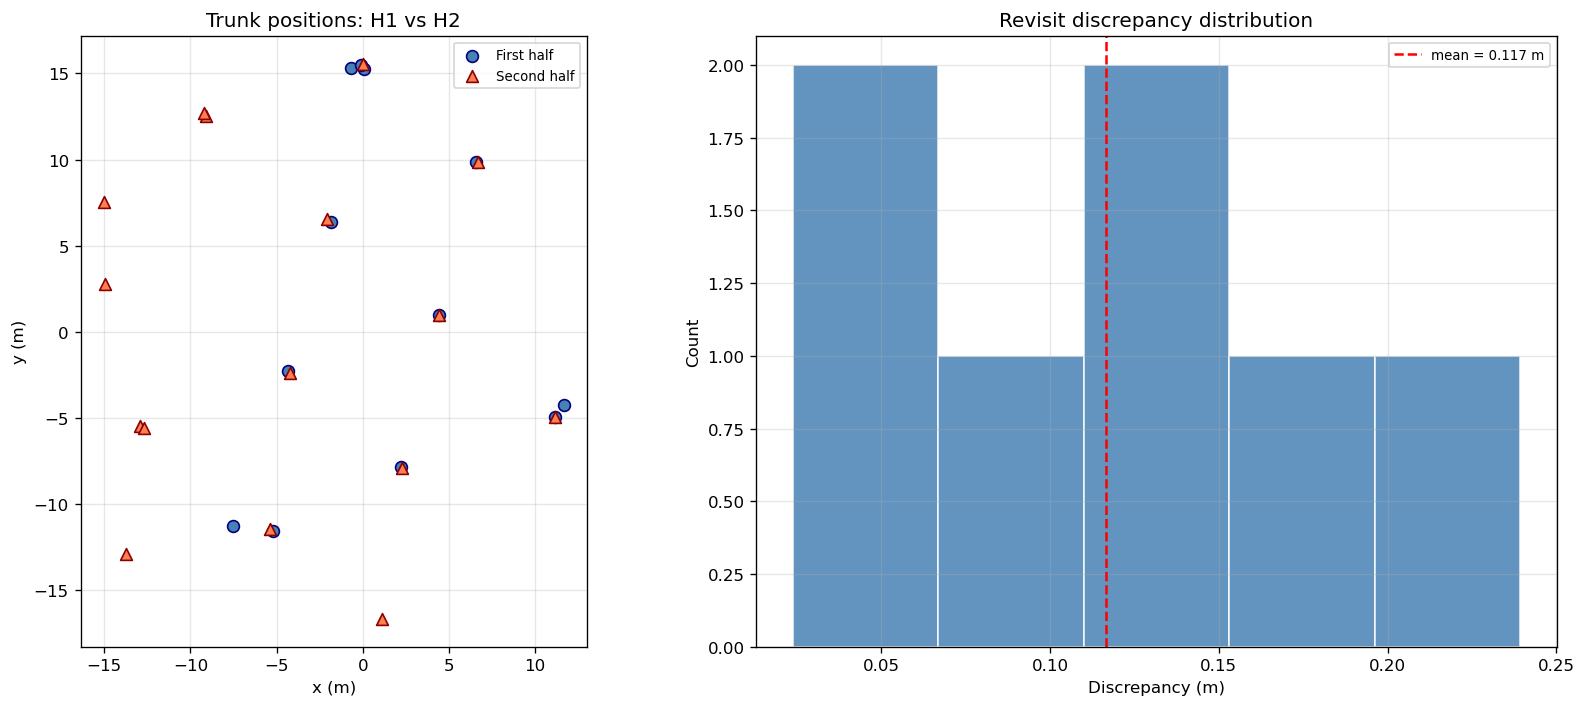

In [63]:
mid_ts = (all_raw[:, 4].min() + all_raw[:, 4].max()) / 2

def mean_positions_per_trunk(data):
    """Return dict {trunk_id: (mean_x, mean_y)}."""
    out = {}
    for tid in np.unique(data[:, 0]):
        rows = data[data[:, 0] == tid]
        out[tid] = (rows[:, 1].mean(), rows[:, 2].mean())
    return out

h1_pos = mean_positions_per_trunk(all_raw[all_raw[:, 4] <= mid_ts])
h2_pos = mean_positions_per_trunk(all_raw[all_raw[:, 4] >  mid_ts])

common_ids = set(h1_pos) & set(h2_pos)
revisit_dists = []
for tid in common_ids:
    dx = h1_pos[tid][0] - h2_pos[tid][0]
    dy = h1_pos[tid][1] - h2_pos[tid][1]
    revisit_dists.append(np.hypot(dx, dy))
revisit_dists = np.array(revisit_dists)
revisit_matched = revisit_dists[revisit_dists <= REVISIT_THRESHOLD]

print(f"Trunks in H1: {len(h1_pos)},  H2: {len(h2_pos)}")
print(f"Common trunks: {len(common_ids)}")
print(f"Within {REVISIT_THRESHOLD}m: {len(revisit_matched)}")
if len(revisit_matched):
    print(f"  Mean discrepancy : {revisit_matched.mean():.4f} m")
    print(f"  Max  discrepancy : {revisit_matched.max():.4f} m")
    print(f"  Std  discrepancy : {revisit_matched.std():.4f} m")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]; ax.set_aspect('equal')
ax.set_title('Trunk positions: H1 vs H2')
for tid in common_ids:
    x1, y1 = h1_pos[tid]; x2, y2 = h2_pos[tid]
    d = np.hypot(x1 - x2, y1 - y2)
    color = 'limegreen' if d <= REVISIT_THRESHOLD else 'orange'
    ax.plot([x1, x2], [y1, y2], '-', color=color, lw=1.2, alpha=0.7)
h1_xy = np.array(list(h1_pos.values()))
h2_xy = np.array(list(h2_pos.values()))
ax.scatter(h1_xy[:,0], h1_xy[:,1], s=50, marker='o', c='steelblue',
           edgecolors='navy', label='First half', zorder=3)
ax.scatter(h2_xy[:,0], h2_xy[:,1], s=50, marker='^', c='coral',
           edgecolors='darkred', label='Second half', zorder=3)
ax.legend(fontsize=8); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

ax = axes[1]; ax.set_title('Revisit discrepancy distribution')
if len(revisit_matched):
    ax.hist(revisit_matched, bins=max(5, len(revisit_matched)//2+1),
            color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(revisit_matched.mean(), color='red', ls='--',
               label=f'mean = {revisit_matched.mean():.3f} m')
    ax.legend(fontsize=8)
ax.set_xlabel('Discrepancy (m)'); ax.set_ylabel('Count')
fig.tight_layout(); plt.show()

## 3 — Plantation grid regularity

Fit a triangular planting grid to the final trunk positions.
The residual measures how well detections conform to the
expected planting geometry — independent of any reference map.

Fitting triangular grid...
  Spacing  : 8.983 m
  Rotation : 18.65°
  Residual : 0.8967 m


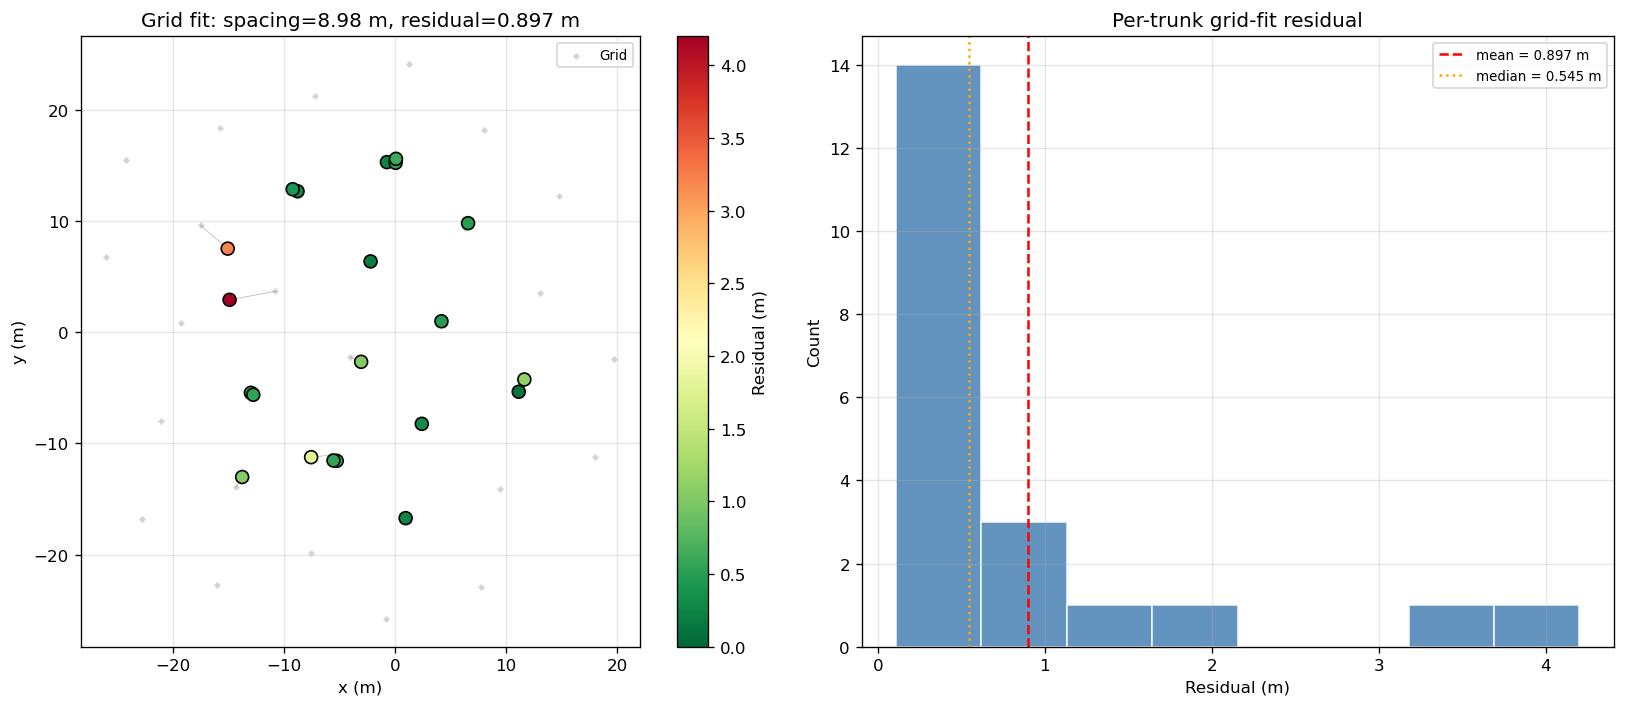


Possible spurious detections (residual > 1.79 m):
  ID 15: (-15.04, 7.54)  residual=3.214 m
  ID 16: (-14.87, 2.93)  residual=4.201 m


In [64]:
trunk_xy = final_trunks[:, 1:3]

def make_tri_grid(spacing, n=15):
    pts = []
    for i in range(-n, n + 1):
        for j in range(-n, n + 1):
            x = j * spacing + (i % 2) * spacing * 0.5
            y = i * spacing * np.sqrt(3) * 0.5
            pts.append([x, y])
    return np.array(pts)

def grid_residual(params, detected):
    spacing, theta, ox, oy = params
    grid = make_tri_grid(spacing)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    grid = (R @ grid.T).T + np.array([ox, oy])
    return cdist(detected, grid).min(axis=1).mean()

cx, cy = trunk_xy.mean(0)
bounds = [GRID_SPACING_RANGE,
          (-np.pi / 3, np.pi / 3),
          (cx - 20, cx + 20),
          (cy - 20, cy + 20)]

print("Fitting triangular grid...")
result = differential_evolution(grid_residual, bounds, args=(trunk_xy,),
                                seed=42, maxiter=150, tol=1e-5, polish=True)
best_spacing, best_theta, best_ox, best_oy = result.x
grid_rmse = result.fun

print(f"  Spacing  : {best_spacing:.3f} m")
print(f"  Rotation : {math.degrees(best_theta):.2f}°")
print(f"  Residual : {grid_rmse:.4f} m")

# Per-trunk residuals
grid_pts = make_tri_grid(best_spacing)
c, s = np.cos(best_theta), np.sin(best_theta)
R_grid = np.array([[c, -s], [s, c]])
grid_pts = (R_grid @ grid_pts.T).T + np.array([best_ox, best_oy])
D_grid = cdist(trunk_xy, grid_pts)
per_trunk_res = D_grid.min(axis=1)
nn_grid_idx = D_grid.argmin(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]; ax.set_aspect('equal')
ax.set_title(f'Grid fit: spacing={best_spacing:.2f} m, residual={grid_rmse:.3f} m')
near = grid_pts[cdist(grid_pts, trunk_xy).min(axis=1) < best_spacing * 1.5]
ax.scatter(near[:,0], near[:,1], s=15, c='lightgray', marker='+', label='Grid')
sc = ax.scatter(trunk_xy[:,0], trunk_xy[:,1], s=60, c=per_trunk_res,
                cmap='RdYlGn_r', edgecolors='k', zorder=3,
                vmin=0, vmax=max(1.0, per_trunk_res.max()))
for i in range(len(trunk_xy)):
    ax.plot([trunk_xy[i,0], grid_pts[nn_grid_idx[i],0]],
            [trunk_xy[i,1], grid_pts[nn_grid_idx[i],1]],
            '-', color='gray', lw=0.5, alpha=0.5)
ax.legend(fontsize=8); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
fig.colorbar(sc, ax=ax, label='Residual (m)')

ax = axes[1]; ax.set_title('Per-trunk grid-fit residual')
ax.hist(per_trunk_res, bins=max(5, len(per_trunk_res)//3+1),
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(per_trunk_res.mean(), color='red', ls='--',
           label=f'mean = {per_trunk_res.mean():.3f} m')
ax.axvline(np.median(per_trunk_res), color='orange', ls=':',
           label=f'median = {np.median(per_trunk_res):.3f} m')
ax.legend(fontsize=8); ax.set_xlabel('Residual (m)'); ax.set_ylabel('Count')
fig.tight_layout(); plt.show()

outlier_thresh = 2.0 * per_trunk_res.mean()
outliers = np.where(per_trunk_res > outlier_thresh)[0]
if len(outliers):
    print(f"\nPossible spurious detections (residual > {outlier_thresh:.2f} m):")
    for idx in outliers:
        print(f"  ID {int(final_trunks[idx,0])}: "
              f"({trunk_xy[idx,0]:.2f}, {trunk_xy[idx,1]:.2f})  "
              f"residual={per_trunk_res[idx]:.3f} m")

## 4 — Per-trunk position stability

For each trunk, measure the **spread** (std) and **drift rate** (linear
position slope) of its position across all marker snapshots over time.

Trunks with ≥5 snapshots: 21
   ID   Snaps  Span(s)   Spread(m)  Drift(mm/s)
--------------------------------------------------
    1    3321    332.0      0.2333        0.239
    2    3321    332.0      0.3564        1.439
    3    3321    332.0      0.2710        1.088
    4    3321    332.0      0.1510        0.581
    6    3315    331.4      0.2253        0.446
    7    3291    329.0      0.2105        0.168
   12    2098    209.7      0.2269        1.816
   14    1474    147.3      0.2486        4.583
   16    1289    128.8      0.2107        0.421
   18     848     84.7      0.2218        3.860
   19     751     75.0      0.2323        6.061
   20     748     74.7      0.1790        6.017
   21     528     52.7      0.2098       10.202
   13      15      1.4      0.2359      419.089
    5      14      1.3      0.0000        0.000
    8       9      0.8      0.0000        0.000
    9       9      0.8      0.0000        0.000
   10       9      0.8      0.0000        0.000
   11   

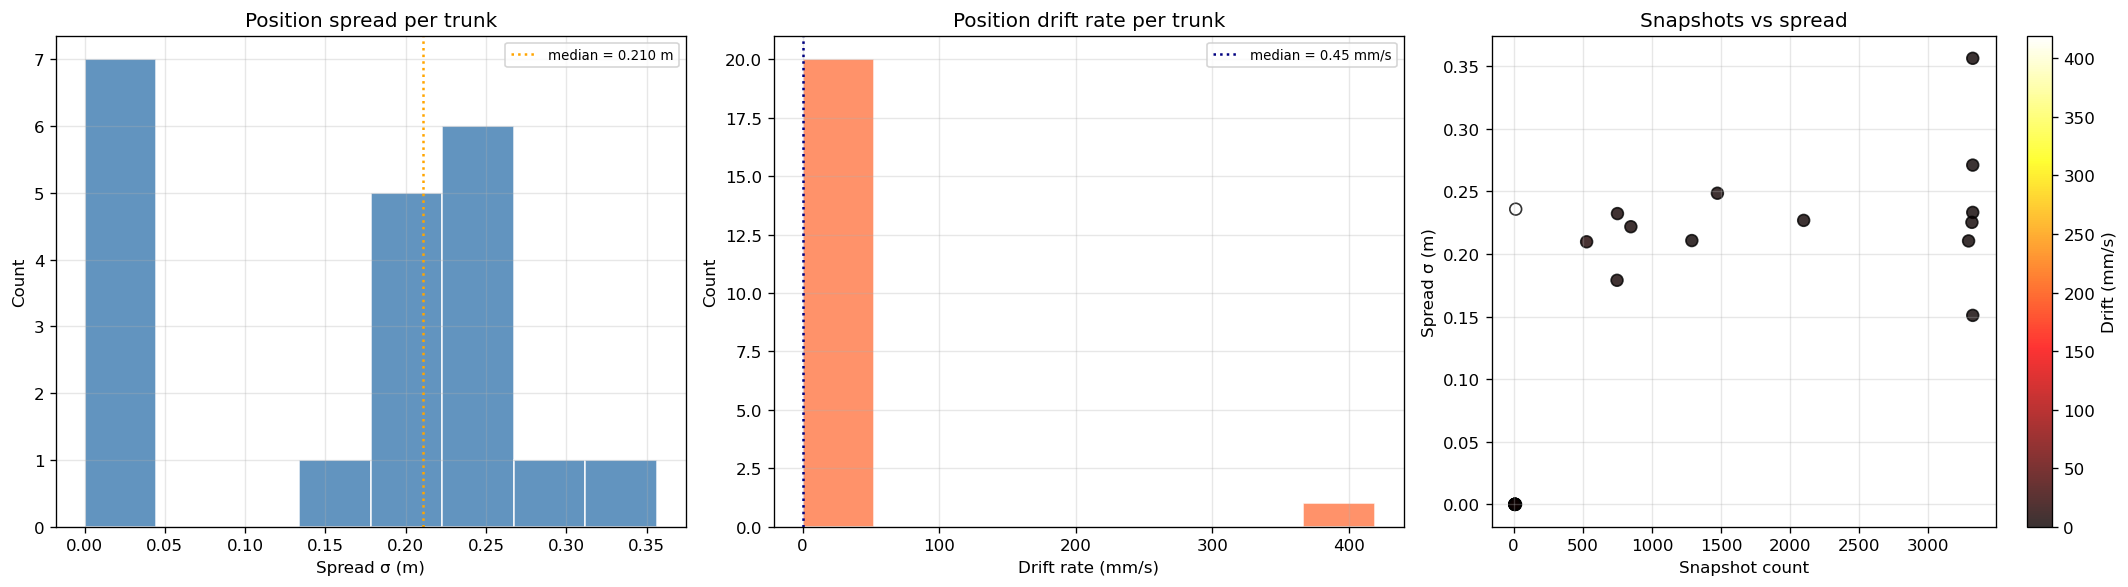

In [65]:
t0 = all_raw[:, 4].min()
trunk_stats = []

for tid in unique_ids:
    rows = all_raw[all_raw[:, 0] == tid]
    if len(rows) < 5:
        continue
    xy = rows[:, 1:3]
    t_s = (rows[:, 4] - t0) / 1e9
    spread = np.sqrt(xy[:, 0].std()**2 + xy[:, 1].std()**2)
    duration = t_s.max() - t_s.min()

    drift_rate = 0.0
    if duration > 1.0:
        cx_fit = np.polyfit(t_s, xy[:, 0], 1)
        cy_fit = np.polyfit(t_s, xy[:, 1], 1)
        drift_rate = np.hypot(cx_fit[0], cy_fit[0])

    trunk_stats.append({
        'id': tid, 'n': len(rows), 'spread': spread,
        'drift_mms': drift_rate * 1000, 'duration': duration,
    })

trunk_stats.sort(key=lambda s: s['n'], reverse=True)
spreads    = np.array([s['spread'] for s in trunk_stats])
drifts_mms = np.array([s['drift_mms'] for s in trunk_stats])
n_snaps    = np.array([s['n'] for s in trunk_stats])

print(f"Trunks with ≥5 snapshots: {len(trunk_stats)}")
print(f"{'ID':>5s}  {'Snaps':>6s}  {'Span(s)':>7s}  {'Spread(m)':>10s}  {'Drift(mm/s)':>11s}")
print('-' * 50)
for s in trunk_stats[:20]:
    print(f"{int(s['id']):5d}  {s['n']:6d}  {s['duration']:7.1f}  "
          f"{s['spread']:10.4f}  {s['drift_mms']:11.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]; ax.set_title('Position spread per trunk')
ax.hist(spreads, bins=max(5, len(spreads)//3+1),
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.median(spreads), color='orange', ls=':',
           label=f'median = {np.median(spreads):.3f} m')
ax.set_xlabel('Spread σ (m)'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

ax = axes[1]; ax.set_title('Position drift rate per trunk')
ax.hist(drifts_mms, bins=max(5, len(drifts_mms)//3+1),
        color='coral', edgecolor='white', alpha=0.85)
ax.axvline(np.median(drifts_mms), color='navy', ls=':',
           label=f'median = {np.median(drifts_mms):.2f} mm/s')
ax.set_xlabel('Drift rate (mm/s)'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

ax = axes[2]; ax.set_title('Snapshots vs spread')
sc = ax.scatter(n_snaps, spreads, c=drifts_mms, cmap='hot',
                edgecolors='k', s=50, alpha=0.8)
ax.set_xlabel('Snapshot count'); ax.set_ylabel('Spread σ (m)')
fig.colorbar(sc, ax=ax, label='Drift (mm/s)')

fig.tight_layout(); plt.show()

## 5 — Summary

In [66]:
print('=' * 55)
print('  GROUND-TRUTH-FREE EVALUATION')
print('=' * 55)
print(f'  Total trunks (active+lost): {len(final_trunks)}')
print('-' * 55)
if len(revisit_matched):
    print(f'  Revisit consistency  : {revisit_matched.mean():.4f} m mean  '
          f'({len(revisit_matched)} matched trunks)')
else:
    print(f'  Revisit consistency  : N/A')
print(f'  Grid-fit residual    : {grid_rmse:.4f} m mean  '
      f'(spacing={best_spacing:.2f} m)')
if len(spreads):
    print(f'  Trunk spread         : {np.median(spreads):.4f} m median')
    print(f'  Trunk drift rate     : {np.median(drifts_mms):.3f} mm/s median')
print('-' * 55)
print('  Interpretation:')

rev_val = revisit_matched.mean() if len(revisit_matched) else float('nan')
rev_ok = rev_val < 0.3
ic = "\u2713" if rev_ok else "\u2717"
cmp = "<" if rev_ok else "\u2265"
lbl = "low" if rev_ok else "elevated"
print(f'    {ic} Revisit {rev_val:.3f} m {cmp} 0.3 m   \u2192 {lbl} odometry drift')

grid_ok = grid_rmse < 0.5
ic = "\u2713" if grid_ok else "\u2717"
cmp = "<" if grid_ok else "\u2265"
lbl = "good" if grid_ok else "poor"
print(f'    {ic} Grid res {grid_rmse:.3f} m {cmp} 0.5 m   \u2192 {lbl} detection accuracy')

if len(spreads):
    spr_val = np.median(spreads)
    spr_ok = spr_val < 0.2
    ic = "\u2713" if spr_ok else "\u2717"
    cmp = "<" if spr_ok else "\u2265"
    lbl = "stable" if spr_ok else "unstable"
    print(f'    {ic} Spread {spr_val:.3f} m {cmp} 0.2 m   \u2192 {lbl} trunk localization')

    dft_val = np.median(drifts_mms)
    dft_ok = dft_val < 5.0
    ic = "\u2713" if dft_ok else "\u2717"
    cmp = "<" if dft_ok else "\u2265"
    lbl = "no" if dft_ok else "possible"
    print(f'    {ic} Drift {dft_val:.3f} mm/s {cmp} 5 mm/s   \u2192 {lbl} systematic position drift')

print('=' * 55)

  GROUND-TRUTH-FREE EVALUATION
  Total trunks (active+lost): 21
-------------------------------------------------------
  Revisit consistency  : 0.1166 m mean  (7 matched trunks)
  Grid-fit residual    : 0.8967 m mean  (spacing=8.98 m)
  Trunk spread         : 0.2105 m median
  Trunk drift rate     : 0.446 mm/s median
-------------------------------------------------------
  Interpretation:
    ✓ Revisit 0.117 m < 0.3 m   → low odometry drift
    ✗ Grid res 0.897 m ≥ 0.5 m   → poor detection accuracy
    ✗ Spread 0.210 m ≥ 0.2 m   → unstable trunk localization
    ✓ Drift 0.446 mm/s < 5 mm/s   → no systematic position drift


---

# C — Alignment Quality Metrics

Quantify the agreement between the satellite-derived reference tree map
(`tree_centers_local.csv`) and the online trunk detections.  Because both
point sets are **sparse landmarks** (tens of trees, not dense surfaces),
the primary metrics are chosen for that regime:

**1. Matched-pair RMSE** (primary accuracy metric):
Hungarian assignment (Kuhn, 1955) finds the optimal 1:1 pairing between
detections and reference trees.  Pairs exceeding a distance threshold are
rejected.  RMSE over confirmed pairs measures alignment accuracy on
known-good correspondences, without contamination from spurious or missed
detections.

**2. Recall** (primary coverage metric):
$$\text{Recall} = \frac{|\text{confirmed pairs}|}{|\mathcal{R}_{\text{area}}|}$$
Fraction of reference trees in the flight area that are matched to a
detection.  Directly answers: *how many trees did we find?*

**3. GMM Correlation Score** (Jian & Vemuri, IEEE TPAMI 2011):
Soft, global measure of spatial agreement robust to differing set sizes.
Each point set is represented as a Gaussian mixture with bandwidth
$\sigma$; the normalised inner product gives a score in $[0,1]$:
$$\rho = \frac{\sum_{d,r} \exp\!\bigl(-\|d-r\|^2 / 4\sigma^2\bigr)}
              {\sqrt{\sum_{d,d'}\exp\!\bigl(-\|d-d'\|^2/4\sigma^2\bigr)\;
                     \sum_{r,r'}\exp\!\bigl(-\|r-r'\|^2/4\sigma^2\bigr)}}$$

**4. Mean nearest-neighbour distance** (supplementary):
$$\bar{d}_{\text{NN}} = \frac{1}{|\mathcal{D}|}\sum_{d\in\mathcal{D}} \min_{r\in\mathcal{R}} \|d - r\|$$
Provides a quick sanity check, but mixes alignment error with detection
coverage — an unmatched detection far from any reference inflates the
mean even if the alignment itself is accurate.  Use matched-pair RMSE for
cleaner interpretation.

## 9 — Compute alignment quality metrics

Load reference tree centers from CSV (same local frame as odom: drone
takeoff = origin).  Rigid alignment correction (DE + Procrustes) followed
by Voronoi-cell deduplication.  Then Hungarian assignment for paired
matching, matched-pair RMSE, recall, GMM correlation, and mean NN distance.

In [67]:
!pip install shapely

Defaulting to user installation because normal site-packages is not writeable


In [68]:
import pandas as pd

# ── Load reference tree centers ──────────────────────────────────────
ref_df = pd.read_csv(REF_CSV_PATH)
ref_centers = ref_df[["x_local", "y_local"]].values
print(f"Reference trees: {len(ref_centers)}")

# ── Detected trunk positions (odom frame ≈ local frame) ─────────────
det_pts = final_trunks[:, 1:3]
print(f"Detected trunks: {len(det_pts)}")

# ── Restrict reference to flight bounding box ────────────────────────
pad = 5.0
flight_bbox_min = det_pts.min(axis=0) - pad
flight_bbox_max = det_pts.max(axis=0) + pad
in_area = ((ref_centers[:, 0] >= flight_bbox_min[0]) &
           (ref_centers[:, 0] <= flight_bbox_max[0]) &
           (ref_centers[:, 1] >= flight_bbox_min[1]) &
           (ref_centers[:, 1] <= flight_bbox_max[1]))
ref_in_area = ref_centers[in_area]
print(f"Reference trees in flight area: {len(ref_in_area)} / {len(ref_centers)}")

# ── Rigid alignment correction  (DE + iterative Procrustes) ─────────
det_pts_orig = det_pts.copy()
det_centroid = det_pts.mean(axis=0)

TRIM_FRAC = 0.75
ICP_ITERS = 10
ICP_INLIER_MULT = 1.5

def _apply_rigid(theta, dx, dy, pts, centroid):
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    return (R @ (pts - centroid).T).T + centroid + np.array([dx, dy])

def _neg_gmm_3(params, det, ref, centroid, sigma):
    xf = _apply_rigid(*params, det, centroid)
    D = cdist(xf, ref)
    return -np.exp(-D ** 2 / (4 * sigma ** 2)).sum()

def _trimmed_chamfer_3(params, det, ref, centroid, keep_n):
    xf = _apply_rigid(*params, det, centroid)
    nn = np.sort(cdist(xf, ref).min(axis=1))[:keep_n]
    return nn.mean()

keep_n = max(3, int(len(det_pts) * TRIM_FRAC))
chamfer_before = _trimmed_chamfer_3(
    [0, 0, 0], det_pts, ref_in_area, det_centroid, keep_n)

# Stage 1: global search via GMM correlation
res_gmm = differential_evolution(
    _neg_gmm_3,
    bounds=[(-np.pi / 4, np.pi / 4), (-5, 5), (-5, 5)],
    args=(det_pts, ref_in_area, det_centroid, GMM_SIGMA),
    seed=42, maxiter=400, tol=1e-9, polish=True,
)

# Stage 2: local refinement with trimmed Chamfer
res_tc = differential_evolution(
    _trimmed_chamfer_3,
    bounds=[
        (res_gmm.x[0] - np.radians(5), res_gmm.x[0] + np.radians(5)),
        (res_gmm.x[1] - 2, res_gmm.x[1] + 2),
        (res_gmm.x[2] - 2, res_gmm.x[2] + 2),
    ],
    args=(det_pts, ref_in_area, det_centroid, keep_n),
    seed=42, maxiter=400, tol=1e-9, polish=True,
)

best_de = (res_tc.x if
    _trimmed_chamfer_3(res_tc.x, det_pts, ref_in_area, det_centroid, keep_n) <=
    _trimmed_chamfer_3(res_gmm.x, det_pts, ref_in_area, det_centroid, keep_n)
    else res_gmm.x)
cur_pts = _apply_rigid(*best_de, det_pts, det_centroid)

# Stage 3: iterative Procrustes on inlier pairs
for _it in range(ICP_ITERS):
    D_icp = cdist(cur_pts, ref_in_area)
    ri_h, ci_h = linear_sum_assignment(D_icp)
    dists_h = np.array([D_icp[r, c_] for r, c_ in zip(ri_h, ci_h)])
    inlier_thr = ICP_INLIER_MULT * np.median(dists_h)
    inlier = dists_h <= inlier_thr
    if inlier.sum() < 3:
        break
    src = cur_pts[ri_h[inlier]]
    dst = ref_in_area[ci_h[inlier]]
    mu_s, mu_d = src.mean(0), dst.mean(0)
    H = (src - mu_s).T @ (dst - mu_d)
    U, _, Vt = np.linalg.svd(H)
    R_p = Vt.T @ U.T
    if np.linalg.det(R_p) < 0:
        Vt[-1] *= -1
        R_p = Vt.T @ U.T
    t_p = mu_d - R_p @ mu_s
    prev_pts = cur_pts.copy()
    cur_pts = (R_p @ cur_pts.T).T + t_p
    if np.max(np.linalg.norm(cur_pts - prev_pts, axis=1)) < 1e-6:
        break

# Recover total transform for reporting
mu_o, mu_f = det_pts.mean(0), cur_pts.mean(0)
H_t = (det_pts - mu_o).T @ (cur_pts - mu_f)
U, _, Vt = np.linalg.svd(H_t)
R_tot = Vt.T @ U.T
if np.linalg.det(R_tot) < 0:
    Vt[-1] *= -1
    R_tot = Vt.T @ U.T
align_theta = float(np.arctan2(R_tot[1, 0], R_tot[0, 0]))
t_tot = mu_f - R_tot @ mu_o
align_dx, align_dy = float(t_tot[0]), float(t_tot[1])
det_pts = cur_pts

chamfer_after = _trimmed_chamfer_3(
    [0, 0, 0], det_pts, ref_in_area, det_pts.mean(0), keep_n)

print(f"\nRigid alignment  (DE + Procrustes, {_it+1} iters converged):")
print(f"  Rotation    : {np.degrees(align_theta):+.2f}\u00b0")
print(f"  Translation : ({align_dx:+.3f}, {align_dy:+.3f}) m")
print(f"  Trimmed Chamfer (best {TRIM_FRAC:.0%})")
print(f"    before    : {chamfer_before:.4f} m")
print(f"    after     : {chamfer_after:.4f} m")

# ── Deduplicate detections sharing a Voronoi cell ────────────────────
from scipy.spatial import Voronoi as _Vor
_vor = _Vor(ref_in_area)
_ref_labels = np.argmin(cdist(det_pts, ref_in_area), axis=1)

det_pts_pre_dedup = det_pts.copy()
n_before_dedup = len(det_pts)
merged = {}
for idx, lbl in enumerate(_ref_labels):
    merged.setdefault(lbl, []).append(idx)

new_pts = []
for lbl in sorted(merged):
    idxs = merged[lbl]
    new_pts.append(det_pts[idxs].mean(axis=0))
det_pts = np.array(new_pts)

print(f"\nDeduplication (merge per Voronoi cell):")
print(f"  {n_before_dedup} detections → {len(det_pts)}  "
      f"({n_before_dedup - len(det_pts)} duplicates merged)")

# ── Hungarian matching ───────────────────────────────────────────────
D_cross = cdist(det_pts, ref_in_area)
ri, ci = linear_sum_assignment(D_cross)
matched_dists = np.array([D_cross[r, c] for r, c in zip(ri, ci)])

confirmed_mask = matched_dists <= MATCH_THRESHOLD
confirmed_det = set(ri[confirmed_mask])
confirmed_ref = set(ci[confirmed_mask])

det_only_idx = sorted(set(range(len(det_pts))) - confirmed_det)
ref_only_idx = sorted(set(range(len(ref_in_area))) - confirmed_ref)
confirmed_pairs = [(r, c, D_cross[r, c])
                   for r, c in zip(ri[confirmed_mask], ci[confirmed_mask])]

print(f"\nHungarian matching (threshold={MATCH_THRESHOLD} m):")
print(f"  CONFIRMED : {len(confirmed_pairs):3d}")
print(f"  DET-ONLY  : {len(det_only_idx):3d}")
print(f"  REF-ONLY  : {len(ref_only_idx):3d}")

# ── Mean NN distance (det → ref) ─────────────────────────────────────
nn_dists = D_cross.min(axis=1)
chamfer_mean = nn_dists.mean()
chamfer_rms  = np.sqrt((nn_dists ** 2).mean())
chamfer_med  = np.median(nn_dists)
chamfer_p90  = np.percentile(nn_dists, 90)

print(f"\nMean NN distance (det → ref):")
print(f"  Mean   : {chamfer_mean:.4f} m")
print(f"  RMS    : {chamfer_rms:.4f} m")
print(f"  Median : {chamfer_med:.4f} m")
print(f"  90th % : {chamfer_p90:.4f} m")

# ── Matched-pair RMSE ────────────────────────────────────────────────
if confirmed_pairs:
    cp_d = np.array([p[2] for p in confirmed_pairs])
    matched_rmse = np.sqrt((cp_d ** 2).mean())
    print(f"\nMatched-pair RMSE: {matched_rmse:.4f} m  ({len(confirmed_pairs)} pairs)")
else:
    matched_rmse = float('nan')
    print("\nNo confirmed pairs for RMSE")

# ── Recall ───────────────────────────────────────────────────────────
recall = len(confirmed_pairs) / len(ref_in_area) if len(ref_in_area) else 0.0
print(f"Recall @ {MATCH_THRESHOLD} m : {recall:.2%}  "
      f"({len(confirmed_pairs)}/{len(ref_in_area)})")

# ── GMM Correlation Score ────────────────────────────────────────────
K_cross = np.exp(-D_cross ** 2 / (4 * GMM_SIGMA ** 2))
raw_corr = K_cross.sum()

D_ref = cdist(ref_in_area, ref_in_area)
self_ref = np.exp(-D_ref ** 2 / (4 * GMM_SIGMA ** 2)).sum()

D_det = cdist(det_pts, det_pts)
self_det = np.exp(-D_det ** 2 / (4 * GMM_SIGMA ** 2)).sum()

gmm_score = raw_corr / np.sqrt(self_ref * self_det)
print(f"\nGMM Correlation Score (σ={GMM_SIGMA} m): {gmm_score:.4f}")

# ── Per-reference NN distance (for Voronoi coloring) ─────────────────
nn_ref2det = cdist(ref_in_area, det_pts).min(axis=1)


Reference trees: 63
Detected trunks: 21
Reference trees in flight area: 19 / 63

Rigid alignment  (DE + Procrustes, 3 iters converged):
  Rotation    : +0.39°
  Translation : (-0.199, +0.114) m
  Trimmed Chamfer (best 75%)
    before    : 0.8385 m
    after     : 0.7999 m

Deduplication (merge per Voronoi cell):
  21 detections → 14  (7 duplicates merged)

Hungarian matching (threshold=2.0 m):
  CONFIRMED :  12
  DET-ONLY  :   2
  REF-ONLY  :   7

Mean NN distance (det → ref):
  Mean   : 1.3941 m
  RMS    : 1.8721 m
  Median : 0.9332 m
  90th % : 3.1300 m

Matched-pair RMSE: 1.0006 m  (12 pairs)
Recall @ 2.0 m : 63.16%  (12/19)

GMM Correlation Score (σ=2.0 m): 0.7501


## 10 — Voronoi alignment map + NN distance histogram

**Left:** Voronoi tessellation of reference trees colored by distance to
nearest detection.  Grey cells have no detection within `MATCH_THRESHOLD`.
Arrows show displacement from each detection to its matched reference.

**Right:** Distribution of per-detection nearest-neighbor distances with
summary statistics.

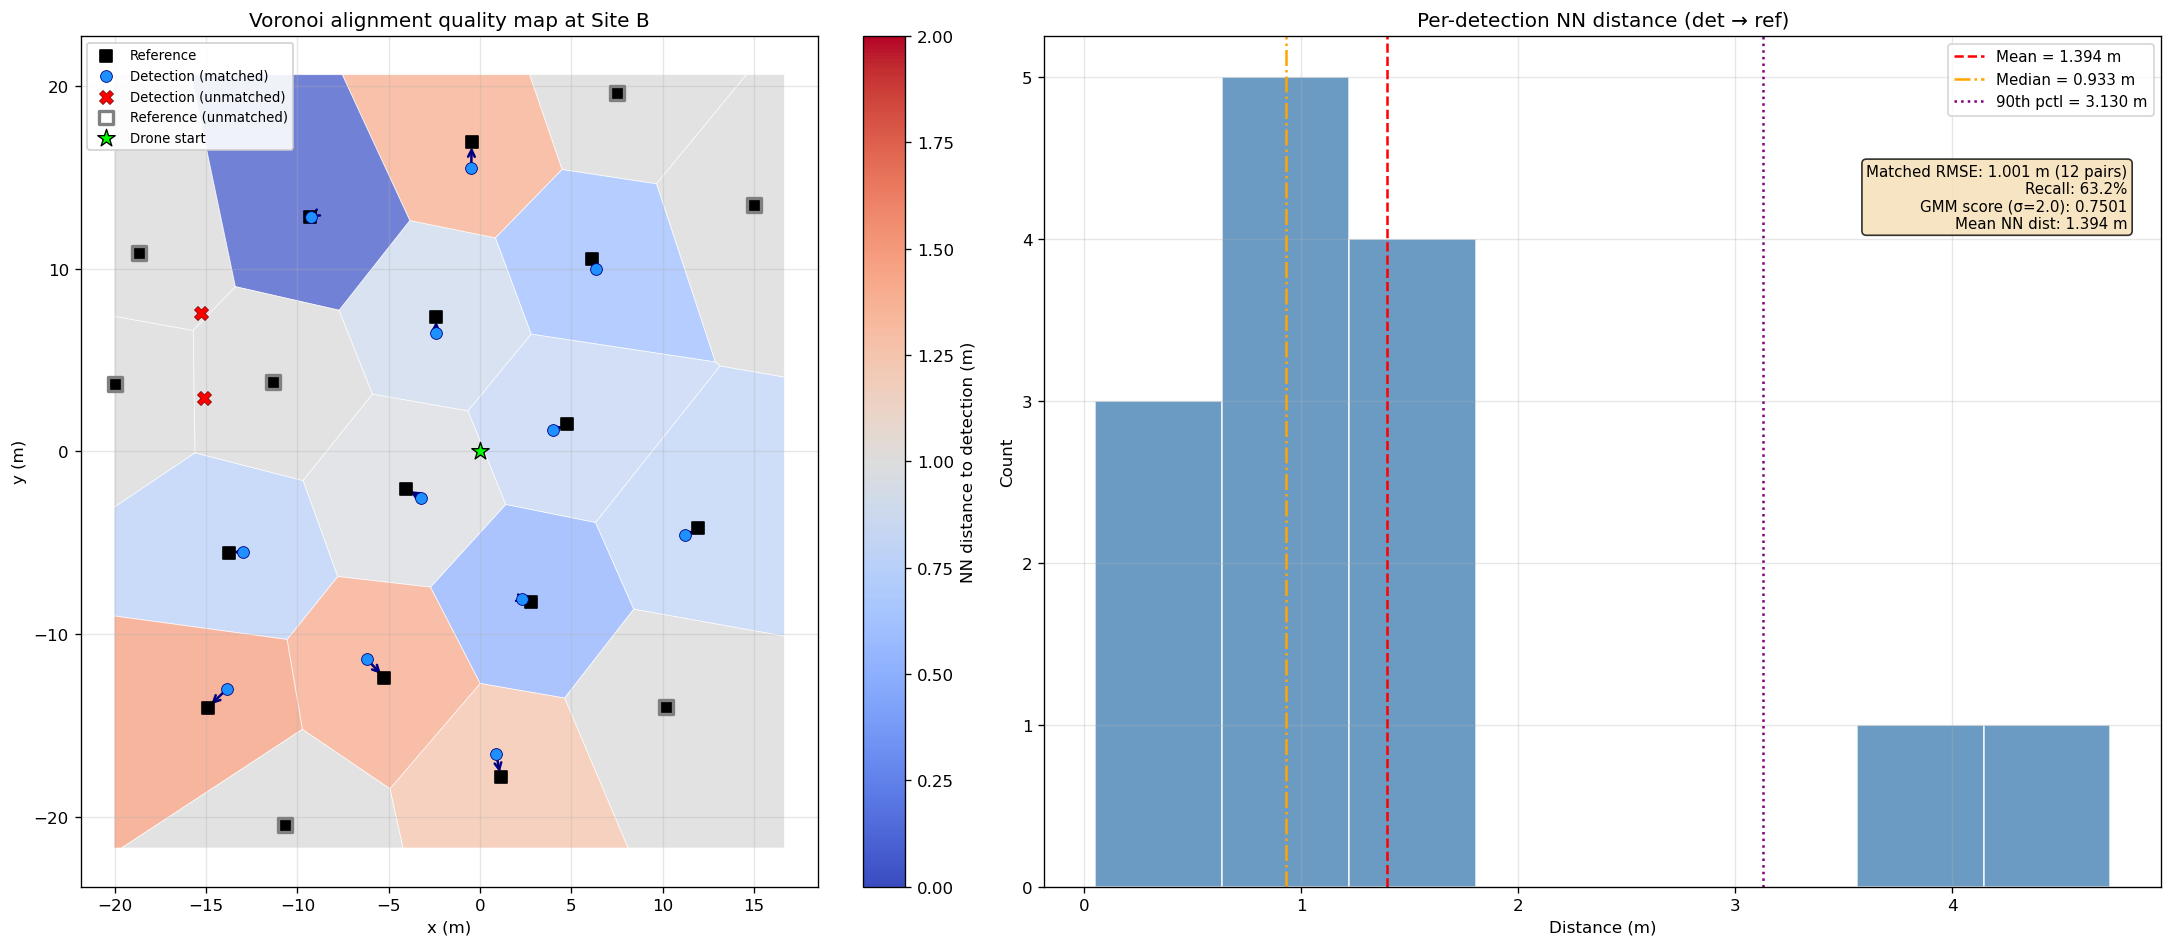

In [69]:
from matplotlib.collections import PolyCollection
from shapely.geometry import Polygon as ShapelyPoly, box as shapely_box


def voronoi_finite_polygons(vor, bbox):
    """Clip Voronoi regions to a bounding box, returning one polygon per point."""
    clip_box = shapely_box(*bbox)
    polys = []
    for idx in range(len(vor.points)):
        reg_idx = vor.point_region[idx]
        region = vor.regions[reg_idx]
        if not region or -1 in region:
            big = shapely_box(bbox[0] - 500, bbox[1] - 500,
                              bbox[2] + 500, bbox[3] + 500)
            poly = big
            for other_idx in range(len(vor.points)):
                if other_idx == idx:
                    continue
                mid = (vor.points[idx] + vor.points[other_idx]) / 2.0
                diff = vor.points[other_idx] - vor.points[idx]
                d = np.linalg.norm(diff)
                if d < 1e-12:
                    continue
                n = diff / d
                perp = np.array([-n[1], n[0]])
                far = 1000.0
                half = ShapelyPoly([
                    mid - perp * far - n * far,
                    mid + perp * far - n * far,
                    mid + perp * far,
                    mid - perp * far,
                ])
                poly = poly.intersection(half)
                if poly.is_empty:
                    break
            poly = poly.intersection(clip_box)
        else:
            verts = vor.vertices[region]
            poly = ShapelyPoly(verts).intersection(clip_box)

        if poly.is_empty or not hasattr(poly, 'exterior'):
            polys.append(None)
        else:
            polys.append(np.array(poly.exterior.coords))
    return polys


# ── Build Voronoi ────────────────────────────────────────────────────
bbox = (flight_bbox_min[0], flight_bbox_min[1],
        flight_bbox_max[0], flight_bbox_max[1])
vor = Voronoi(ref_in_area)
polys = voronoi_finite_polygons(vor, bbox)

# ── Color mapping ────────────────────────────────────────────────────
vmax_color = MATCH_THRESHOLD
cmap = plt.cm.coolwarm
cnorm = plt.Normalize(vmin=0, vmax=vmax_color)
unmatched_color = (0.85, 0.85, 0.85, 1.0)

# ── Figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── LEFT: Voronoi + arrows ───────────────────────────────────────────
ax = axes[0]
ax.set_aspect("equal")
ax.set_title("Voronoi alignment quality map at Site B")

for i, poly_coords in enumerate(polys):
    if poly_coords is None:
        continue
    is_unmatched = nn_ref2det[i] > MATCH_THRESHOLD
    fc = unmatched_color if is_unmatched else cmap(cnorm(nn_ref2det[i]))
    ax.fill(poly_coords[:, 0], poly_coords[:, 1],
            fc=fc, ec='white', lw=0.5, alpha=0.75)

ax.scatter(ref_in_area[:, 0], ref_in_area[:, 1],
           s=50, c='black', marker='s', zorder=5, label='Reference')

# if det_pts_pre_dedup is not None and len(det_pts_pre_dedup) != len(det_pts):
#     ax.scatter(det_pts_pre_dedup[:, 0], det_pts_pre_dedup[:, 1],
#                s=25, facecolors='none', edgecolors='orange',
#                marker='o', linewidths=1, zorder=3, alpha=0.5,
#                label=f'Detection (pre-dedup, n={len(det_pts_pre_dedup)})')

for di, ri_idx, d in confirmed_pairs:
    ax.annotate('',
                xy=(ref_in_area[ri_idx, 0], ref_in_area[ri_idx, 1]),
                xytext=(det_pts[di, 0], det_pts[di, 1]),
                arrowprops=dict(arrowstyle='->', color='navy',
                                lw=1.5, shrinkA=0, shrinkB=3))
conf_det_xy = det_pts[list(confirmed_det)]
ax.scatter(conf_det_xy[:, 0], conf_det_xy[:, 1],
           s=50, c='dodgerblue', marker='o', zorder=5,
           edgecolors='navy', linewidths=0.5, label='Detection (matched)')

if det_only_idx:
    det_only_xy = det_pts[det_only_idx]
    ax.scatter(det_only_xy[:, 0], det_only_xy[:, 1],
               s=70, c='red', marker='X', zorder=5,
               edgecolors='darkred', linewidths=0.5,
               label='Detection (unmatched)')

if ref_only_idx:
    ref_only_xy = ref_in_area[ref_only_idx]
    ax.scatter(ref_only_xy[:, 0], ref_only_xy[:, 1],
               s=70, facecolors='none', edgecolors='gray',
               marker='s', linewidths=2, zorder=5,
               label='Reference (unmatched)')

ax.scatter(0, 0, s=120, c='lime', marker='*', zorder=6,
           edgecolors='black', linewidths=0.8, label='Drone start')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=cnorm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("NN distance to detection (m)")

ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

# ── RIGHT: Histogram ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(nn_dists, bins=max(8, len(nn_dists) // 2), color='steelblue',
         edgecolor='white', alpha=0.8)
ax2.axvline(chamfer_mean, color='red', ls='--', lw=1.5,
            label=f'Mean = {chamfer_mean:.3f} m')
ax2.axvline(chamfer_med, color='orange', ls='-.', lw=1.5,
            label=f'Median = {chamfer_med:.3f} m')
ax2.axvline(chamfer_p90, color='purple', ls=':', lw=1.5,
            label=f'90th pctl = {chamfer_p90:.3f} m')
ax2.set_title("Per-detection NN distance (det → ref)")
ax2.set_xlabel("Distance (m)")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)

ax2.text(0.97, 0.85,
         f"Matched RMSE: {matched_rmse:.3f} m ({len(confirmed_pairs)} pairs)\n"
         f"Recall: {recall:.1%}\n"
         f"GMM score (\u03c3={GMM_SIGMA}): {gmm_score:.4f}\n"
         f"Mean NN dist: {chamfer_mean:.3f} m",
         transform=ax2.transAxes, fontsize=9, va='top', ha='right',
         bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))

fig.tight_layout()
plt.show()


## 11 — Alignment quality summary

In [75]:
print("=" * 60)
print("  ALIGNMENT QUALITY METRICS  (after correction + dedup)")
print("=" * 60)
print(f"  Reference trees (flight area) : {len(ref_in_area)}")
print(f"  Detected trunks               : {n_before_dedup} raw \u2192 {len(det_pts)} after dedup")
print("-" * 60)
print(f"  Rigid correction applied  (DE + Procrustes)")
print(f"    Rotation                    : {np.degrees(align_theta):+.2f}\u00b0")
print(f"    Translation                 : ({align_dx:+.3f}, {align_dy:+.3f}) m")
print("-" * 60)
print(f"  Hungarian matching (\u2264{MATCH_THRESHOLD} m)")
print(f"    Confirmed pairs             : {len(confirmed_pairs)}")
print(f"    Matched-pair RMSE           : {matched_rmse:.4f} m")
print(f"    Recall                      : {recall:.2%}")
print(f"    DET-ONLY (spurious/new)     : {len(det_only_idx)}")
print(f"    REF-ONLY (missed)           : {len(ref_only_idx)}")
print("-" * 60)
print(f"  GMM Correlation (\u03c3={GMM_SIGMA} m)     : {gmm_score:.4f}")
print("-" * 60)
print(f"  Mean NN distance (det\u2192ref)       [supplementary]")
print(f"    Mean                        : {chamfer_mean:.4f} m")
print(f"    Median                      : {chamfer_med:.4f} m")
print(f"    90th percentile             : {chamfer_p90:.4f} m")
print("-" * 60)
print("  Interpretation:")

if matched_rmse < 0.5:
    rm_icon, rm_label = "\u2713", "excellent alignment accuracy"
elif matched_rmse < 1.0:
    rm_icon, rm_label = "\u2713", "good alignment accuracy"
elif matched_rmse < 1.5:
    rm_icon, rm_label = "~", "moderate alignment accuracy"
else:
    rm_icon, rm_label = "\u2717", "poor alignment accuracy"
print(f"    {rm_icon} Matched RMSE {matched_rmse:.3f} m \u2192 {rm_label}")

if recall >= 0.8:
    rc_icon, rc_label = "\u2713", "strong detection coverage"
elif recall >= 0.6:
    rc_icon, rc_label = "\u2713", "adequate detection coverage"
elif recall >= 0.4:
    rc_icon, rc_label = "~", "low detection coverage"
else:
    rc_icon, rc_label = "\u2717", "poor detection coverage"
print(f"    {rc_icon} Recall {recall:.1%} \u2192 {rc_label}")

gmm_ok = gmm_score > 0.5
gmm_icon = "\u2713" if gmm_ok else "\u2717"
gmm_cmp = ">" if gmm_ok else "\u2264"
gmm_lbl = "strong" if gmm_ok else "weak"
print(f"    {gmm_icon} GMM {gmm_score:.4f} {gmm_cmp} 0.5 \u2192 {gmm_lbl} spatial agreement")

print("=" * 60)


  ALIGNMENT QUALITY METRICS  (after correction + dedup)
  Reference trees (flight area) : 19
  Detected trunks               : 21 raw → 14 after dedup
------------------------------------------------------------
  Rigid correction applied  (DE + Procrustes)
    Rotation                    : +0.39°
    Translation                 : (-0.199, +0.114) m
------------------------------------------------------------
  Hungarian matching (≤2.0 m)
    Confirmed pairs             : 12
    Matched-pair RMSE           : 1.0006 m
    Recall                      : 63.16%
    DET-ONLY (spurious/new)     : 2
    REF-ONLY (missed)           : 7
------------------------------------------------------------
  GMM Correlation (σ=2.0 m)     : 0.7501
------------------------------------------------------------
  Mean NN distance (det→ref)       [supplementary]
    Mean                        : 1.3941 m
    Median                      : 0.9332 m
    90th percentile             : 3.1300 m
---------------------